# Validate the wind-speed correction for Paris PM2.5

I use this notebook to reproduce the mean-based wind-speed comparison in Renard and Surcin (2025). Their approach separates hourly PM2.5 measurements into wind conditions below and above 6 m/s. The purpose is to check the Geod'Air and ERA5 processing before applying more advanced methods later in the dissertation.

The data are validated hourly PM2.5 measurements from Geod'Air and 10 m wind components from ERA5. I also check whether a possible one-hour timestamp offset changes the result.

This validation remains restricted to 2013-2024 so that it matches the period used in the source paper. The dissertation's main empirical analysis uses 2013-2025. The paper averages the available Airparif network, whereas the main calculation here uses FR04329 because it has observations in every year. This is therefore a check of the paper's method and direction of result, not an exact reproduction of its dataset. A citywide sensitivity check is included later.

## References

**Main method**
- Renard, J.-B. and Surcin, J. (2025). PM2.5 Pollution Decrease in Paris, France, for the 2013-2024 Period: An Evaluation of the Local Source Contributions by Subtracting the Effect of Wind Speed. Sensors 25(21), 6566. [Article and supplementary information](https://doi.org/10.3390/s25216566).

**Data**
- Geod'Air national air-quality database (INERIS/LCSQA): validated hourly PM2.5 observations. [Database description](https://www.geodair.fr/a-propos).
- Copernicus Climate Change Service. ERA5 hourly data on single levels from 1940 to present. [Dataset and citation](https://doi.org/10.24381/cds.adbb2d47).
- Hersbach, H. et al. (2020). The ERA5 global reanalysis. Quarterly Journal of the Royal Meteorological Society 146, 1999-2049. [Article](https://doi.org/10.1002/qj.3803).
- European Centre for Medium-Range Weather Forecasts (ECMWF) (2026). *ERA5: How to calculate wind speed and wind direction from u and v components of the wind?* Copernicus Knowledge Base. [Guidance](https://confluence.ecmwf.int/spaces/CKB/pages/133262398/ERA5+How+to+calculate+wind+speed+and+wind+direction+from+u+and+v+components+of+the+wind).

**Inference**
- Durbin, J. and Watson, G.S. (1950, 1951). Testing for serial correlation in least squares regression, I and II. Biometrika 37, 409-428 and 38, 159-178. [Part I](https://doi.org/10.1093/biomet/37.3-4.409) and [Part II](https://doi.org/10.1093/biomet/38.1-2.159).
- Efron, B. (1979). Bootstrap methods: another look at the jackknife. Annals of Statistics 7, 1-26. [Article](https://doi.org/10.1214/aos/1176344552).
- Wu, C.F.J. (1986). Jackknife, bootstrap and other resampling methods in regression analysis. Annals of Statistics 14, 1261-1295. [Article](https://doi.org/10.1214/aos/1176350142).
- Mammen, E. (1993). Bootstrap and wild bootstrap for high dimensional linear models. Annals of Statistics 21, 255-285. [Article](https://doi.org/10.1214/aos/1176349025).
- Davidson, R. and Flachaire, E. (2008). The wild bootstrap, tamed at last. Journal of Econometrics 146, 162-169. [Accessible working paper](https://qed.econ.queensu.ca/working_papers/papers/qed_wp_1000.pdf).
- Fieller, E.C. (1954). Some problems in interval estimation. Journal of the Royal Statistical Society, Series B 16, 175-185. [Article](https://doi.org/10.1111/j.2517-6161.1954.tb00159.x).
- Cook, R.D. (1977). Detection of influential observation in linear regression. Technometrics 19(1), 15-18. [Article](https://doi.org/10.1080/00401706.1977.10489493).
- Belsley, D.A., Kuh, E. and Welsch, R.E. (1980). Regression Diagnostics: Identifying Influential Data and Sources of Collinearity. Wiley. [Publisher record and DOI](https://onlinelibrary.wiley.com/doi/book/10.1002/0471725153)

**Data conventions**
- Jiang, N. et al. (2023). On thresholds for controlling negative particle (PM2.5) readings in air quality reporting. Environmental Monitoring and Assessment 195(10), 1187. [Article](https://doi.org/10.1007/s10661-023-11750-4).

**Code provenance**
- Durbin-Watson is calculated with the documented [`statsmodels.stats.stattools.durbin_watson`](https://www.statsmodels.org/stable/generated/statsmodels.stats.stattools.durbin_watson.html) function. Leverage, studentised residuals and Cook's distance come from the documented [`OLSInfluence`](https://www.statsmodels.org/stable/generated/st
- The Fieller code evaluates the quadratic inequality described by Fieller (1954) using the coefficient covariance matrix returned by the documented [`statsmodels RegressionResults.cov_params`](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.RegressionResults.cov_params.html) method. It is written in this notebook because `statsmodels` does not provide a ready-made Fieller interval for the slope-to-starting-value ratio.
- The paired residual bootstrap is implemented directly in this notebook. NumPy's documented [`Generator.integers`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.integers.html) method draws residual-pair indices with replacement, and [`scipy.stats.linregress`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.linregress.html) refits the two trend lines. The wild bootstrap uses NumPy's documented [`Generator.choice`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.choice.html) method to select `-1` or `+1` with equal probability, producing the Rademacher signs. These resampling loops are notebook implementations of the cited bootstrap principles rather than calls to a ready-made `statsmodels` bootstrap function.

**Software**
- statsmodels: Seabold, S. and Perktold, J. (2010). statsmodels: econometric and statistical modeling with Python. Proceedings of the 9th Python in Science Conference, 92-96.
- xarray: Hoyer, S. and Hamman, J. (2017). xarray: N-D labeled arrays and datasets in Python. Journal of Open Research Software 5(1), 10.
- cdsapi: Copernicus Climate Data Store API client.
- pandas: McKinney, W. (2010). Data structures for statistical computing in Python. Proceedings of the 9th Python in Science Conference, 56-61.
- numpy: Harris, C.R. et al. (2020). Array programming with NumPy. Nature 585, 357-362.
- scipy: Virtanen, P. et al. (2020). SciPy 1.0: fundamental algorithms for scientific computing in Python. Nature Methods 17, 261-272.
- matplotlib: Hunter, J.D. (2007). Matplotlib: a 2D graphics environment. Computing in Science and Engineering 9(3), 90-95.


## 1. Read the Geod'Air files

The Geod'Air exports cannot be loaded with the default pandas settings because the lines have outer quotes, doubled internal quotes and semicolon separators. The functions below clean the file and parse the two date formats found in the exports.

In [1]:
import io
import os

import pandas as pd
import numpy as np
import xarray as xr

def load_geodair(path):
    """Read one of the quoted, semicolon-separated Geod'Air files."""
    with open(path, encoding='utf-8-sig') as f:
        raw = f.read()
    clean_lines = []
    for line in raw.splitlines():
        if not line:
            continue
        if line.startswith('"') and line.endswith('"'):
            line = line[1:-1]
        clean_lines.append(line.replace('""', '"'))
    csv_text = io.StringIO("\n".join(clean_lines))
    df = pd.read_csv(csv_text, sep=';', quotechar='"', engine='python')
    df.columns = [c.strip().strip('"') for c in df.columns]
    return df

def parse_geodair_dates(values):
    """Parse both date formats found in the yearly exports."""
    values = values.astype(str)
    dates = pd.Series(pd.NaT, index=values.index, dtype="datetime64[ns]")
    slash_format = values.str.contains("/", na=False)
    dates[slash_format] = pd.to_datetime(
        values[slash_format], format="%Y/%m/%d %H:%M:%S", errors="coerce"
    )
    dates[~slash_format] = pd.to_datetime(
        values[~slash_format], format="%Y-%m-%d %H:%M:%S", errors="coerce"
    )
    assert dates.notna().all(), f"{dates.isna().sum()} timestamps failed to parse"
    return dates

## 2. Load the 2013-2024 hourly files

There is one file for each year of the paper-comparison period. I list the expected years explicitly so that a later 2025 file cannot enter this notebook by accident.

In [2]:
hourly_files = [
    f"Donnee_pm2.5_paris/Donnees_hourly_yearly/pm2.5_paris_{year}_hourly.csv"
    for year in range(2013, 2025)
]
missing_hourly = [path for path in hourly_files if not os.path.exists(path)]
assert not missing_hourly, f"Missing Geod'Air files: {missing_hourly}"
hourly = pd.concat([load_geodair(f) for f in hourly_files], ignore_index=True)
print("Files loaded:", len(hourly_files), "(2013-2024 paper-comparison window)")
print("Combined shape:", hourly.shape)
print("Stations:", hourly["code site"].unique())

Files loaded: 12 (2013-2024 paper-comparison window)
Combined shape: (280335, 23)
Stations: <ArrowStringArray>
['FR04143', 'FR04329', 'FR04055', 'FR04004', 'FR04131', 'FR04031']
Length: 6, dtype: str


## 3. Keep valid measurements

I keep observations for which Geod'Air reports `validité == 1` and convert the concentration column to numeric form.

Valid negative readings are retained because they can occur near the instrument detection limit. Removing them would truncate the lower tail and bias the averages upward. I compare both treatments later because the source paper does not state how it handled negative readings.

In [3]:
hourly_valid = hourly[hourly["validité"] == 1].copy()
hourly_valid["valeur brute"] = pd.to_numeric(hourly_valid["valeur brute"], errors="coerce")
hourly_valid = hourly_valid.dropna(subset=["valeur brute"])
hourly_valid["datetime"] = parse_geodair_dates(hourly_valid["Date de début"])
assert hourly_valid["datetime"].dt.year.between(2013, 2024).all(), "timestamp outside paper-comparison window"

print("Valid rows:", len(hourly_valid))
print("Negative readings retained:", (hourly_valid["valeur brute"] < 0).sum())
print(hourly_valid["valeur brute"].describe().round(2))

Valid rows: 267583
Negative readings retained: 543
count    267583.00
mean         13.60
std          10.52
min          -2.98
25%           6.90
50%          10.62
75%          17.05
max         169.98
Name: valeur brute, dtype: float64


## 4. Check the changing station coverage

The number of available stations changes during the period. Some stations enter in 2019 or 2022 and have lower average concentrations than FR04329. Averaging whichever stations are available each year could therefore exaggerate the downward trend.

For the main validation I use FR04329 because it has observations in every year. This keeps the station identity fixed, but it does not make one traffic station representative of the whole city. The later citywide analysis uses station fixed effects, and section 10j below gives a separate network-average sensitivity check.

In [4]:
hourly_valid["year"] = hourly_valid["datetime"].dt.year
per_station = hourly_valid.pivot_table(index="year", columns="code site",
                                       values="valeur brute", aggfunc="mean")
print("Per-station annual mean PM2.5 (ug/m3):")
print(per_station.round(1))

Per-station annual mean PM2.5 (ug/m3):
code site  FR04004  FR04031  FR04055  FR04131  FR04143  FR04329
year                                                           
2013           NaN      NaN      NaN      NaN     18.7     22.2
2014           NaN      NaN      NaN      NaN     15.3     20.1
2015           NaN      NaN      NaN      NaN     14.3     20.1
2016           NaN      NaN      NaN      NaN     14.5     18.2
2017           NaN      NaN      NaN      NaN     14.2     16.1
2018           NaN      NaN      NaN      NaN     14.4     16.2
2019           NaN      NaN     12.1      NaN     13.7     15.5
2020           NaN      NaN     10.4      NaN      NaN     13.9
2021           NaN      NaN     12.2      NaN      NaN     15.3
2022          12.4      6.1     12.4     11.4      NaN     14.8
2023          10.4     10.3     10.4      9.5      NaN     13.2
2024           7.4      9.1      9.7      7.9      NaN     10.5


## 5. Select FR04329

FR04329 is the only station with observations in every year from 2013-2024. Its record has missing hours, so I describe it as spanning the full period rather than as complete or uninterrupted.

In [5]:
fr04329 = hourly_valid[hourly_valid["code site"] == "FR04329"].sort_values("datetime").copy()
print("FR04329 rows:", len(fr04329))
print("Date range:", fr04329["datetime"].min(), "to", fr04329["datetime"].max())
print("Years:", sorted(fr04329["datetime"].dt.year.unique()))

FR04329 rows: 102155
Date range: 2013-01-01 00:00:00 to 2024-12-31 22:00:00
Years: [np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024)]


## 6. Timestamp checks

ERA5 timestamps are in UTC, so I first inspect the 2013 daylight-saving transitions. Around both transitions, the Geod'Air labels advance one hour at a time without the skip or repeated hour expected in local civil time. This rules out ordinary local civil time but does not distinguish UTC from a constant UTC+1 label. A later sensitivity check tests whether this remaining one-hour uncertainty affects the trends.

In [6]:
spring = fr04329[(fr04329["datetime"] >= "2013-03-31 00:00") &
                 (fr04329["datetime"] <= "2013-03-31 05:00")]
autumn = fr04329[(fr04329["datetime"] >= "2013-10-27 00:00") &
                 (fr04329["datetime"] <= "2013-10-27 05:00")]
print("Spring transition (31 Mar 2013): 02:00 is present")
print(spring[["datetime", "valeur brute"]].to_string(index=False))
print("\nAutumn transition (27 Oct 2013): 02:00 is not repeated")
print(autumn[["datetime", "valeur brute"]].to_string(index=False))

Spring transition (31 Mar 2013): 02:00 is present
           datetime  valeur brute
2013-03-31 00:00:00        68.725
2013-03-31 01:00:00        57.225
2013-03-31 02:00:00        60.175
2013-03-31 03:00:00        50.550
2013-03-31 04:00:00        54.400
2013-03-31 05:00:00        54.325

Autumn transition (27 Oct 2013): 02:00 is not repeated
           datetime  valeur brute
2013-10-27 00:00:00         7.875
2013-10-27 01:00:00         7.125
2013-10-27 02:00:00         7.750
2013-10-27 03:00:00         5.075
2013-10-27 04:00:00         4.700
2013-10-27 05:00:00         4.925


### Diurnal-cycle check

I also compare winter and summer hourly profiles. The peaks occur at different hours, so PM2.5 does not provide a clear timestamp answer from the traffic cycle alone. I retain the graph as a diagnostic and rely on the later one-hour sensitivity test.

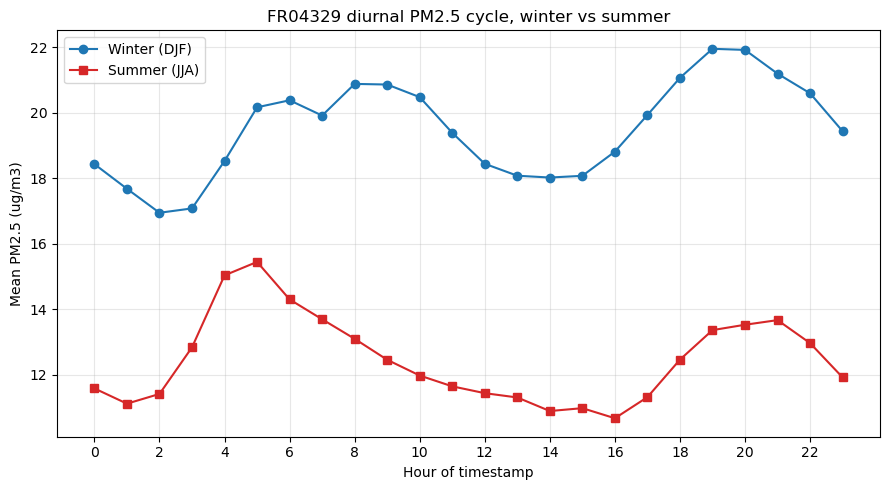

Winter morning peak at hour: 8 value 20.9
Summer morning peak at hour: 5 value 15.4


In [7]:
import matplotlib.pyplot as plt

station_profile = fr04329.copy()
station_profile["hour"] = station_profile["datetime"].dt.hour
station_profile["month"] = station_profile["datetime"].dt.month
winter = station_profile[station_profile["month"].isin([12, 1, 2])].groupby("hour")["valeur brute"].mean()
summer = station_profile[station_profile["month"].isin([6, 7, 8])].groupby("hour")["valeur brute"].mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(winter.index, winter.values, "o-", label="Winter (DJF)", color="tab:blue")
ax.plot(summer.index, summer.values, "s-", label="Summer (JJA)", color="tab:red")
ax.set_xlabel("Hour of timestamp")
ax.set_ylabel("Mean PM2.5 (ug/m3)")
ax.set_title("FR04329 diurnal PM2.5 cycle, winter vs summer")
ax.set_xticks(range(0, 24, 2))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Winter morning peak at hour:", winter.loc[5:11].idxmax(), "value", round(winter.loc[5:11].max(),1))
print("Summer morning peak at hour:", summer.loc[4:11].idxmax(), "value", round(summer.loc[4:11].max(),1))

## 7. Download ERA5 wind data

The cell downloads hourly 10 m wind components from the ERA5 single-level dataset, with one NetCDF file per year. The source paper says that ERA5 was spatially averaged over Paris but does not report its exact extraction box. I use a small rectangle enclosing Paris, `[49.0, 2.0, 48.7, 2.6]`, as a reproducible approximation. Existing files are not downloaded again.

In [8]:
import cdsapi
era5_client = cdsapi.Client()
os.makedirs("data/raw/era5", exist_ok=True)

for year in range(2013, 2025):
    output_path = f"data/raw/era5/era5_paris_wind_{year}.nc"
    if os.path.exists(output_path):
        print(f"{year} already present, skipping")
        continue
    print(f"Requesting {year}...")
    era5_client.retrieve("reanalysis-era5-single-levels", {
        "product_type": "reanalysis",
        "variable": ["10m_u_component_of_wind", "10m_v_component_of_wind"],
        "year": str(year),
        "month": [f"{m:02d}" for m in range(1, 13)],
        "day":   [f"{d:02d}" for d in range(1, 32)],
        "time":  [f"{h:02d}:00" for h in range(24)],
        "area":  [49.0, 2.0, 48.7, 2.6],
        "data_format": "netcdf",
    }, output_path)
    print(f"{year} done")

2013 already present, skipping
2014 already present, skipping
2015 already present, skipping
2016 already present, skipping
2017 already present, skipping
2018 already present, skipping
2019 already present, skipping
2020 already present, skipping
2021 already present, skipping
2022 already present, skipping
2023 already present, skipping
2024 already present, skipping


## 8. Calculate hourly wind speed

ERA5 provides the east-west and north-south components of wind at 10 m, labelled `u10` and `v10`, rather than a single hourly wind-speed variable. For each grid cell, I calculate the magnitude of the horizontal wind vector as `sqrt(u10^2 + v10^2)`, following the standard conversion documented by [ECMWF](https://confluence.ecmwf.int/spaces/CKB/pages/133262398/ERA5+How+to+calculate+wind+speed+and+wind+direction+from+u+and+v+components+of+the+wind).

I calculate the speed at each grid cell before taking the spatial average because averaging the signed components first could allow winds in opposing directions to cancel. I then take the unweighted mean across the cells in the small Paris box. Equal weighting is a reasonable approximation over this limited latitude range.

Renard and Surcin (2025) use ERA5 wind speed at 10 m and report that between 6% and 13% of hourly values exceed 6 m/s, depending on the year. I calculate the same annual proportion as a processing check. For each hour, the condition `wind > 6` is either true or false. Taking its mean gives the proportion of hours above the threshold because Python treats true as 1 and false as 0. Multiplying by 100 expresses this proportion as a percentage. I calculate it for the complete period and separately by year.

In [9]:
era5_files = [
    f"data/raw/era5/era5_paris_wind_{year}.nc"
    for year in range(2013, 2025)
]
missing_era5 = [path for path in era5_files if not os.path.exists(path)]
assert not missing_era5, f"Missing ERA5 files: {missing_era5}"
yearly_wind = []
for era5_file in era5_files:
    ds = xr.open_dataset(era5_file)
    wind_speed = np.hypot(ds["u10"], ds["v10"]).mean(dim=["latitude", "longitude"])
    yearly_wind.append(wind_speed.to_series())
    ds.close()
wind = pd.concat(yearly_wind).sort_index()
wind.index.name = "datetime"
wind.name = "wind"

print("Wind files used:", len(era5_files))
print("Wind hours:", len(wind))
print(wind.describe().round(2))
overall_high_wind = (wind > 6).mean() * 100
annual_high_wind = (wind > 6).groupby(wind.index.year).mean() * 100
print(f"Overall hours above 6 m/s: {overall_high_wind:.1f} percent")
print("Annual percentage of hours above 6 m/s:")
print(annual_high_wind.round(1).to_string())
print(f"Annual range: {annual_high_wind.min():.1f} to {annual_high_wind.max():.1f} percent "
      "(paper: 6 to 13 percent)")

Wind files used: 12
Wind hours: 105192
count    105192.00
mean          3.53
std           1.75
min           0.16
25%           2.19
50%           3.22
75%           4.54
max          14.40
Name: wind, dtype: float64
Overall hours above 6 m/s: 9.6 percent
Annual percentage of hours above 6 m/s:
datetime
2013     7.7
2014     8.4
2015    10.4
2016     7.9
2017     7.4
2018     8.0
2019    10.9
2020    13.8
2021     9.2
2022     7.9
2023    13.9
2024     9.9
Annual range: 7.4 to 13.9 percent (paper: 6 to 13 percent)


## 9. Match PM2.5 and wind observations

I join the two series by hourly timestamp and keep hours for which both PM2.5 and wind speed are available.

In [10]:
pm = fr04329.set_index("datetime")["valeur brute"].rename("pm25")
merged = pd.concat([pm, wind], axis=1, sort=False).dropna()
merged["year"] = merged.index.year
print("Merged hours:", len(merged))
print(merged[["pm25", "wind"]].describe().round(2))

Merged hours: 102155
            pm25       wind
count  102155.00  102155.00
mean       16.37       3.52
std        11.76       1.74
min        -2.55       0.16
25%         8.60       2.19
50%        13.20       3.21
75%        20.70       4.53
max       169.98      14.40


## 10. Compare annual trends by wind condition

Following Renard and Surcin, I fit a straight line to the annual means and divide its slope by the fitted concentration in the first year. I calculate this for all hours, wind below 6 m/s and wind above 6 m/s.

The directional check is whether the high-wind trend is shallower than the unfiltered trend. This is not a pass-fail validation of the whole paper. The exact percentages can differ because the paper averages the available Airparif network, while the primary calculation here uses one traffic station and only the paper's annual-mean estimator.

In [11]:
from scipy import stats

def annual_mean(d):
    return d.groupby("year")["pm25"].mean()

ann_all  = annual_mean(merged)
ann_low  = annual_mean(merged[merged["wind"] < 6])
ann_high = annual_mean(merged[merged["wind"] > 6])

def annual_trend(annual_series):
    x = annual_series.index.values.astype(float)
    res = stats.linregress(x, annual_series.values)
    first_fit = res.slope * x[0] + res.intercept
    return 100 * res.slope / first_fit, res.rvalue**2

for label, ann, paper in [("all hours",   ann_all,  "-4.8"),
                          ("wind < 6",    ann_low,  "-4.8"),
                          ("wind > 6",    ann_high, "-4.1")]:
    t, r2 = annual_trend(ann)
    print(f"{label:10s}: {t:+5.1f} %/yr   (R2 = {r2:.2f})   paper approx {paper}")

t_all, _  = annual_trend(ann_all)
t_high, _ = annual_trend(ann_high)
print("\nGap check (>6 m/s trend shallower than unfiltered?):")
print(f"  all {t_all:+.1f}  vs  >6 m/s {t_high:+.1f}  ->",
      "same direction as paper" if t_high > t_all else "different direction, investigate")

all hours :  -4.1 %/yr   (R2 = 0.90)   paper approx -4.8
wind < 6  :  -4.1 %/yr   (R2 = 0.90)   paper approx -4.8
wind > 6  :  -2.9 %/yr   (R2 = 0.56)   paper approx -4.1

Gap check (>6 m/s trend shallower than unfiltered?):
  all -4.1  vs  >6 m/s -2.9  -> same direction as paper


## 10a. Sensitivity to negative readings

The main calculation keeps valid negative readings, but the source paper does not explain how it treated them. I therefore repeat the trends after dropping negatives. This shows whether that choice changes the result.

In [12]:
def merge_with_negative_rule(drop_negatives):
    data = hourly[hourly["validité"] == 1].copy()
    data["valeur brute"] = pd.to_numeric(data["valeur brute"], errors="coerce")
    data = data.dropna(subset=["valeur brute"])
    if drop_negatives:
        data = data[data["valeur brute"] >= 0]
    data["datetime"] = parse_geodair_dates(data["Date de début"])
    station_pm = data[data["code site"] == "FR04329"].set_index("datetime")["valeur brute"].rename("pm25")
    result = pd.concat([station_pm, wind], axis=1, sort=False).dropna()
    result["year"] = result.index.year
    return result

rows = []
for label, drop in [("retained (primary)", False), ("dropped (check)", True)]:
    test_data = merge_with_negative_rule(drop)
    t_all, _ = annual_trend(annual_mean(test_data))
    t_low, _ = annual_trend(annual_mean(test_data[test_data["wind"] < 6]))
    t_high, _ = annual_trend(annual_mean(test_data[test_data["wind"] > 6]))
    rows.append({"negatives": label,
                 "all hours": round(t_all, 2),
                 "wind < 6":  round(t_low, 2),
                 "wind > 6":  round(t_high, 2),
                 "gap": round(t_high - t_all, 2),
                 "n hours": len(test_data)})

sens = pd.DataFrame(rows).set_index("negatives")
print(sens.to_string())
print("\nDelta, retained minus dropped (percentage points per year):")
print((sens.drop(columns="n hours").loc["retained (primary)"]
       - sens.drop(columns="n hours").loc["dropped (check)"]).round(3).to_string())

                    all hours  wind < 6  wind > 6   gap  n hours
negatives                                                       
retained (primary)      -4.12     -4.09     -2.86  1.26   102155
dropped (check)         -4.10     -4.07     -2.76  1.34   102045

Delta, retained minus dropped (percentage points per year):
all hours   -0.02
wind < 6    -0.02
wind > 6    -0.10
gap         -0.08


### One-hour timestamp sensitivity

The diurnal profile did not resolve whether the fixed Geod'Air label should be aligned directly with UTC or shifted from a constant UTC+1 convention. I therefore shift PM2.5 back by one hour and repeat the merge. The high-wind fraction and trend gap change only slightly, so the result is not sensitive to this possible offset.

In [13]:
# Alternative interpretation: Geod'Air labels are one hour ahead of UTC.
pm_shifted = fr04329.set_index("datetime")["valeur brute"].rename("pm25")
pm_shifted.index = pm_shifted.index - pd.Timedelta(hours=1)
merged_shift = pd.concat([pm_shifted, wind], axis=1, sort=False).dropna()
merged_shift["year"] = merged_shift.index.year

def trend_from_hourly(data):
    return annual_trend(annual_mean(data))[0]

print("Wind fraction >6 m/s:")
print(f"  direct UTC alignment:    {(merged['wind']>6).mean()*100:.1f}%")
print(f"  one-hour shift from UTC+1: {(merged_shift['wind']>6).mean()*100:.1f}%")
print("\nTrends under each alignment:")
as_is_all = trend_from_hourly(merged)
as_is_high = trend_from_hourly(merged[merged["wind"] > 6])
shifted_all = trend_from_hourly(merged_shift)
shifted_high = trend_from_hourly(merged_shift[merged_shift["wind"] > 6])
print(f"  as-is    -> all: {as_is_all:+.1f}, >6: {as_is_high:+.1f}, gap: {as_is_high-as_is_all:+.2f}")
print(f"  shifted  -> all: {shifted_all:+.1f}, >6: {shifted_high:+.1f}, gap: {shifted_high-shifted_all:+.2f}")

Wind fraction >6 m/s:
  direct UTC alignment:    9.6%
  one-hour shift from UTC+1: 9.6%

Trends under each alignment:
  as-is    -> all: -4.1, >6: -2.9, gap: +1.26
  shifted  -> all: -4.1, >6: -2.7, gap: +1.38


## 10b. Approximate slope-based confidence intervals

The source paper reports the slope standard error divided by the first fitted concentration. I extend that calculation to an approximate 95% interval using a t critical value. It is only approximate because it treats the fitted starting concentration as fixed even though that value is also estimated. The Fieller intervals in section 10f account for uncertainty in both parts of the ratio. The high-wind estimate is expected to be less precise because it is based on fewer hourly observations.

In [14]:
def approximate_trend_ci(ann, label):
    x = ann.index.values.astype(float)
    y = ann.values
    res = stats.linregress(x, y)
    n = len(x)
    tcrit = stats.t.ppf(0.975, df=n - 2)
    slope_lo = res.slope - tcrit * res.stderr
    slope_hi = res.slope + tcrit * res.stderr
    first_fit = res.slope * x[0] + res.intercept
    pct = 100 * res.slope / first_fit
    pct_bounds = sorted([100 * slope_lo / first_fit, 100 * slope_hi / first_fit])
    print(f"{label:12s}: {pct:+5.1f} %/yr   95% CI [{pct_bounds[0]:+.1f}, {pct_bounds[1]:+.1f}]   "
          f"(slope {res.slope:+.3f} +/- {tcrit*res.stderr:.3f}, R2={res.rvalue**2:.2f}, n={n})")
    return pct, pct_bounds

print("Approximate slope-based 95% confidence intervals:\n")
_ = approximate_trend_ci(ann_all,  "all hours")
_ = approximate_trend_ci(ann_low,  "wind < 6")
_ = approximate_trend_ci(ann_high, "wind > 6")

Approximate slope-based 95% confidence intervals:

all hours   :  -4.1 %/yr   95% CI [-5.1, -3.2]   (slope -0.872 +/- 0.202, R2=0.90, n=12)
wind < 6    :  -4.1 %/yr   95% CI [-5.0, -3.1]   (slope -0.901 +/- 0.209, R2=0.90, n=12)
wind > 6    :  -2.9 %/yr   95% CI [-4.6, -1.1]   (slope -0.315 +/- 0.195, R2=0.56, n=12)


## 10c. Paired residual bootstrap (secondary check)

The unfiltered and high-wind trends use the same years, so independent resampling would discard information about how they move together. I therefore resample their fitted residuals as year pairs and refit both lines. The residuals are multiplied by `sqrt(n/(n-2))` because two regression parameters have been fitted and the raw residual variance is too small in this twelve-year sample. This paired construction is a notebook choice based on the bootstrap principle in Efron (1979). I keep it as a secondary check because section 10e also adjusts for leverage.

In [15]:
rng = np.random.default_rng(42)

common_years = ann_all.index.intersection(ann_high.index)
x = common_years.values.astype(float)
y_all  = ann_all.loc[common_years].values
y_high = ann_high.loc[common_years].values
n = len(x)

def fit_parameters(x, y):
    res = stats.linregress(x, y)
    return res.slope, res.intercept

def trend_from_fit(slope, intercept, x):
    first_fit = slope * x[0] + intercept
    return 100 * slope / first_fit

s_all, i_all = fit_parameters(x, y_all)
s_high, i_high = fit_parameters(x, y_high)

resid_all  = y_all  - (s_all  * x + i_all)
resid_high = y_high - (s_high * x + i_high)
infl = np.sqrt(n / (n - 2))
resid_pairs = np.column_stack([resid_all, resid_high]) * infl

gap_point = trend_from_fit(s_high, i_high, x) - trend_from_fit(s_all, i_all, x)

n_boot = 5000
gaps, trends_all, trends_high = [], [], []
for _ in range(n_boot):
    idx = rng.integers(0, n, size=n)
    boot_all  = (s_all  * x + i_all)  + resid_pairs[idx, 0]
    boot_high = (s_high * x + i_high) + resid_pairs[idx, 1]
    bs_all, bi_all = fit_parameters(x, boot_all)
    bs_high, bi_high = fit_parameters(x, boot_high)
    t_all = trend_from_fit(bs_all, bi_all, x)
    t_high = trend_from_fit(bs_high, bi_high, x)
    gaps.append(t_high - t_all)
    trends_all.append(t_all)
    trends_high.append(t_high)

gaps = np.array(gaps)
lo, hi = np.percentile(gaps, [2.5, 97.5])

print(f"Paired residual bootstrap ({n_boot} resamples, seed 42):\n")
print(f"Gap (>6 trend minus unfiltered), point estimate: {gap_point:+.2f} %/yr")
print(f"  bootstrap mean: {gaps.mean():+.2f} %/yr")
print(f"  95% CI: [{lo:+.2f}, {hi:+.2f}] %/yr")
print(f"  excludes zero: {'YES' if lo > 0 else 'NO - not significant at 95%'}")
print()
# Intervals for the individual trends from the same bootstrap draws.
for name, arr in [("all hours", trends_all), ("wind > 6", trends_high)]:
    a = np.array(arr)
    print(f"{name:10s}: {a.mean():+.1f} %/yr, 95% CI [{np.percentile(a,2.5):+.1f}, {np.percentile(a,97.5):+.1f}]")

Paired residual bootstrap (5000 resamples, seed 42):

Gap (>6 trend minus unfiltered), point estimate: +1.26 %/yr
  bootstrap mean: +1.28 %/yr
  95% CI: [+0.40, +2.24] %/yr
  excludes zero: YES

all hours : -4.1 %/yr, 95% CI [-4.8, -3.4]
wind > 6  : -2.8 %/yr, 95% CI [-4.1, -1.5]


### Interpreting the bootstrap result

The interval for the difference excludes zero. This can happen even though the two individual intervals overlap, because both trends come from the same station and years and therefore move together. The wild-bootstrap result below is used for the main inference.

## 10d. Residual autocorrelation in the annual series

Before running the wild bootstrap, I check whether consecutive annual residuals are serially correlated. Strong dependence could make independent year-by-year sign changes understate uncertainty. I report the lag-one correlation and the Durbin-Watson statistic, where a value close to 2 suggests little first-order autocorrelation.

The 0.5 lag-correlation threshold is a practical rule used here, not a value taken from the Durbin-Watson papers. I set it before choosing the bootstrap blocks: above 0.5 in absolute value I use two-year sign blocks; otherwise I use individual years. The observed lag-one correlations are 0.235 and 0.169, with Durbin-Watson values of 1.403 and 1.552, so the one-year version is used.

In [16]:
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson

def regression_parts(annual_series):
    x = annual_series.index.values.astype(float)
    y = annual_series.values
    model = sm.OLS(y, sm.add_constant(x)).fit()
    influence = model.get_influence()
    fitted = np.asarray(model.fittedvalues)
    resid = np.asarray(model.resid)
    leverage = influence.hat_matrix_diag
    return x, y, fitted, resid, leverage, model, influence

parts = {"all hours": regression_parts(ann_all), "wind > 6": regression_parts(ann_high)}

rows = []
for label, (x, y, fitted, resid, h, model, influence) in parts.items():
    rows.append({"series": label, "n": len(x),
                 "lag1": round(float(np.corrcoef(resid[:-1], resid[1:])[0, 1]), 3),
                 "durbin_watson": round(float(durbin_watson(resid)), 3)})
autocorrelation = pd.DataFrame(rows)
print(autocorrelation.to_string(index=False))

block_size = 2 if autocorrelation["lag1"].abs().max() > 0.5 else 1
print(f"\nmax |lag-1| = {autocorrelation['lag1'].abs().max():.3f}, threshold 0.5 "
      f"-> wild bootstrap uses {block_size}-year blocks")

   series  n  lag1  durbin_watson
all hours 12 0.235          1.403
 wind > 6 12 0.169          1.552

max |lag-1| = 0.235, threshold 0.5 -> wild bootstrap uses 1-year blocks


## 10e. Wild bootstrap on the trend gap

With only twelve annual observations, the first and last years have more leverage than the middle years. Following the wild-bootstrap reasoning in Wu (1986), Mammen (1993), and Davidson and Flachaire (2008), I keep each year in place and multiply its residual by a random sign. I use `1/(1-h)` scaling to compensate for residual shrinkage at high-leverage years, and the same sign for both series in a given year to preserve their pairing. The 10,000 Rademacher draws use a fixed seed. The trend gap is treated as statistically distinguishable from zero when its 95% percentile interval excludes zero.

In [17]:
n_draws, seed = 10000, 42
assert (ann_all.index.values == ann_high.index.values).all(), "series not year-aligned"

xa, ya, fa, ra, ha, _, _ = parts["all hours"]
xb, yb, fb, rb, hb, _, _ = parts["wind > 6"]
# HC3-style leverage scaling used by the wild bootstrap.
ra_s, rb_s = ra / (1 - ha), rb / (1 - hb)

def trend_from_xy(x, y):
    r = stats.linregress(x, y)
    return 100 * r.slope / (r.slope * x[0] + r.intercept)

rng = np.random.default_rng(seed)
blocks = np.arange(len(xa)) // block_size
draws = np.empty((n_draws, 3))
for i in range(n_draws):
    signs = rng.choice([-1.0, 1.0], size=blocks.max() + 1)[blocks]
    pa = trend_from_xy(xa, fa + signs * ra_s)
    pb = trend_from_xy(xb, fb + signs * rb_s)
    draws[i] = (pa, pb, pb - pa)

gap_point = trend_from_xy(xb, yb) - trend_from_xy(xa, ya)
ci = {k: np.percentile(draws[:, j], [2.5, 97.5])
      for j, k in enumerate(["all", "high", "gap"])}

print(f"{n_draws} draws, seed {seed}, {block_size}-year Rademacher blocks, 1/(1-h) scaling\n")
print(f"all hours : {trend_from_xy(xa, ya):+.2f} %/yr   95% [{ci['all'][0]:+.2f}, {ci['all'][1]:+.2f}]")
print(f"wind > 6  : {trend_from_xy(xb, yb):+.2f} %/yr   95% [{ci['high'][0]:+.2f}, {ci['high'][1]:+.2f}]")
print(f"GAP       : {gap_point:+.2f} %/yr   95% [{ci['gap'][0]:+.2f}, {ci['gap'][1]:+.2f}]   "
      f"{'excludes zero' if ci['gap'][0] > 0 or ci['gap'][1] < 0 else 'includes zero'}")

10000 draws, seed 42, 1-year Rademacher blocks, 1/(1-h) scaling

all hours : -4.12 %/yr   95% [-4.89, -3.29]
wind > 6  : -2.86 %/yr   95% [-4.22, -1.29]
GAP       : +1.26 %/yr   95% [+0.22, +2.47]   excludes zero


## 10f. Fieller interval on the ratio form trends

The percentage trend divides the fitted slope by the fitted concentration in the first year. Fieller's method allows for the covariance and uncertainty in both parts of that ratio. In the code, `[0, 1]` selects the slope from the fitted coefficients and `[1, x0]` selects the fitted value in the first year. Their variances and covariance form a quadratic inequality, whose roots give the confidence limits. A bounded interval indicates that the fitted starting concentration is sufficiently separated from zero; an unbounded result would warn that the ratio is unstable. Fieller applies to each trend separately, while the paired wild bootstrap is used for the difference between trends.

In [18]:
def fieller_interval(x, y, alpha=0.05):
    model = sm.OLS(y, sm.add_constant(x)).fit()
    covariance = np.asarray(model.cov_params())

    # The numerator is the slope; the denominator is the fitted value in the first year.
    numerator_vector = np.array([0.0, 1.0])
    denominator_vector = np.array([1.0, x[0]])
    numerator = numerator_vector @ model.params
    denominator = denominator_vector @ model.params
    var_num = numerator_vector @ covariance @ numerator_vector
    var_den = denominator_vector @ covariance @ denominator_vector
    cov_num_den = numerator_vector @ covariance @ denominator_vector

    critical = stats.t.ppf(1 - alpha / 2, model.df_resid)
    quad_a = denominator**2 - critical**2 * var_den
    if quad_a <= 0:
        return None
    quad_b = -2 * (numerator * denominator - critical**2 * cov_num_den)
    quad_c = numerator**2 - critical**2 * var_num
    discriminant = quad_b**2 - 4 * quad_a * quad_c
    if discriminant < 0:
        return None

    roots = [(-quad_b - np.sqrt(discriminant)) / (2 * quad_a),
             (-quad_b + np.sqrt(discriminant)) / (2 * quad_a)]
    lo, hi = sorted(roots)
    return 100 * lo, 100 * hi

for label, key in [("all hours", "all"), ("wind > 6", "high")]:
    x, y = parts[label][0], parts[label][1]
    f, b = fieller_interval(x, y), ci[key]
    if f is None:
        print(f"{label:10s}: Fieller interval is unbounded; use the bootstrap result")
    else:
        intervals_overlap = not (f[1] < b[0] or f[0] > b[1])
        print(f"{label:10s}: Fieller [{f[0]:+.2f}, {f[1]:+.2f}]   "
              f"bootstrap [{b[0]:+.2f}, {b[1]:+.2f}]   "
              f"{'overlap' if intervals_overlap else 'do not overlap'}")

all hours : Fieller [-4.84, -3.34]   bootstrap [-4.89, -3.29]   overlap
wind > 6  : Fieller [-4.24, -1.21]   bootstrap [-4.22, -1.29]   overlap


## 10g. Leverage in the annual trend fits

This table checks whether particular years have unusually strong influence on the fitted slopes. It reports leverage, internally studentised residuals and Cook's distance using the `statsmodels` OLS influence calculations. The value `2/n` is the mean leverage for a line with an intercept, not an influence cutoff. I show Cook's distance of 1 as a broad warning level and `4/n` as a more sensitive descriptive screen; neither is a formal critical value. No absolute studentised residual exceeds 2. The largest Cook's distance is 0.356 for the 2024 high-wind value: it is below 1 but slightly above `4/n = 0.333`, so this year has some influence and should not be described as negligible.

In [19]:
rows = []
for label, (x, y, fitted, resid, h, model, influence) in parts.items():
    studentised = influence.resid_studentized_internal
    cooks_distance = influence.cooks_distance[0]
    for i, yr in enumerate(x.astype(int)):
        rows.append({"series": label, "year": yr,
                     "leverage": round(float(h[i]), 3),
                     "resid": round(float(resid[i]), 2),
                     "std_resid": round(float(studentised[i]), 2),
                     "cooks_d": round(float(cooks_distance[i]), 3)})
leverage_table = pd.DataFrame(rows)
print(leverage_table.to_string(index=False))
cook_screen = 4 / len(ann_all)
print(f"\nMean leverage 2/n = {2/len(ann_all):.3f} (reference value, not a cutoff)")
print(f"Cook's distance screening value 4/n = {cook_screen:.3f}; broad warning value = 1")
screened = leverage_table[leverage_table["cooks_d"] > cook_screen]
print("Rows above 4/n:")
print(screened[["series", "year", "cooks_d"]].to_string(index=False)
      if len(screened) else "none")

   series  year  leverage  resid  std_resid  cooks_d
all hours  2013     0.295   1.09       1.19    0.298
all hours  2014     0.225  -0.19      -0.20    0.006
all hours  2015     0.169   0.72       0.73    0.054
all hours  2016     0.127  -0.31      -0.30    0.007
all hours  2017     0.099  -1.60      -1.55    0.133
all hours  2018     0.085  -0.58      -0.56    0.015
all hours  2019     0.085  -0.41      -0.40    0.007
all hours  2020     0.099  -1.18      -1.15    0.073
all hours  2021     0.127   1.16       1.15    0.096
all hours  2022     0.169   1.52       1.54    0.241
all hours  2023     0.225   0.82       0.86    0.108
all hours  2024     0.295  -1.05      -1.15    0.278
 wind > 6  2013     0.295  -0.30      -0.35    0.025
 wind > 6  2014     0.225  -0.14      -0.15    0.003
 wind > 6  2015     0.169   1.53       1.60    0.262
 wind > 6  2016     0.127   0.12       0.12    0.001
 wind > 6  2017     0.099  -1.81      -1.82    0.182
 wind > 6  2018     0.085  -0.16      -0.16   

## 10h. Hours at exactly the cutoff

The paper uses strict inequalities, so an hour at exactly 6 m/s would fall into neither group. I count these hours and compare `> 6` with `>= 6` to see whether the choice matters.

In [20]:
exact = int((merged["wind"] == 6.0).sum())
near  = int(merged["wind"].between(5.995, 6.005).sum())
print(f"hours with wind exactly 6.000: {exact} of {len(merged)}")
print(f"hours within 0.005 of 6:       {near}\n")

for label, sub in [("strict, wind > 6", merged[merged["wind"] > 6]),
                   ("inclusive, wind >= 6", merged[merged["wind"] >= 6])]:
    ann = annual_mean(sub)
    x = ann.index.values.astype(float)
    res = stats.linregress(x, ann.values)
    t = trend_from_fit(res.slope, res.intercept, x)
    print(f"  {label:22s}: {t:+.3f} %/yr   (n = {len(sub)})")

hours with wind exactly 6.000: 0 of 102155
hours within 0.005 of 6:       68

  strict, wind > 6      : -2.860 %/yr   (n = 9761)
  inclusive, wind >= 6  : -2.860 %/yr   (n = 9761)


## 10i. Compare the two trend definitions

Notebook 03 uses a log-linear trend, whereas this paper-comparison exercise uses the source paper's slope-to-starting-value ratio. They don't need to give the same percentage. The following calculation applies both definitions to the same 2013-2024 year grid.

In [21]:
x = ann_all.index.values.astype(float)
r_log = -stats.linregress(x, np.log(ann_all.values)).slope
pure = np.exp(-r_log * (x - x[0]))
T = x[-1] - x[0]

res_obs = stats.linregress(x, ann_all.values)
obs = trend_from_fit(res_obs.slope, res_obs.intercept, x)

res_pure = stats.linregress(x, pure)
exact = trend_from_fit(res_pure.slope, res_pure.intercept, x)

print(f"log-linear rate r            : {r_log:.4f}/yr  ({100*(np.exp(-r_log)-1):+.2f} %/yr)")
print(f"ratio form, observed data    : {obs:+.3f} %/yr")
print(f"ratio form, pure exponential : {exact:+.3f} %/yr   exact on this year grid")
print(f"continuous-time approximation: {-100*(1-np.exp(-r_log*T))/T:+.3f} %/yr   for comparison")

log-linear rate r            : 0.0541/yr  (-5.27 %/yr)
ratio form, observed data    : -4.124 %/yr
ratio form, pure exponential : -4.149 %/yr   exact on this year grid
continuous-time approximation: -4.079 %/yr   for comparison


## 10j. Apply the estimator to a citywide average

The main calculation uses FR04329 because it has observations in every year. For a result closer to the paper's network average, I also average all available Paris stations hour by hour before applying the same estimator. This still cannot be treated as an exact reproduction because the station set changes during the period and the paper does not publish every data-processing detail.

In [22]:
city = hourly_valid.groupby("datetime")["valeur brute"].mean().rename("pm25")
city_m = pd.concat([city, wind], axis=1, sort=False).dropna()
city_m["year"] = city_m.index.year

def city_trend(sub):
    ann = annual_mean(sub)
    x = ann.index.values.astype(float)
    res = stats.linregress(x, ann.values)
    return trend_from_fit(res.slope, res.intercept, x), res

for label, sub in [("all hours", city_m),
                   ("wind < 6", city_m[city_m["wind"] < 6]),
                   ("wind > 6", city_m[city_m["wind"] > 6])]:
    t, res = city_trend(sub)
    print(f"citywide {label:10s}: {t:+.2f} %/yr   (R2 {res.rvalue**2:.2f})")

gap_city = city_trend(city_m[city_m["wind"] > 6])[0] - city_trend(city_m)[0]
print(f"\ncitywide gap : {gap_city:+.2f} %/yr")
print(f"FR04329 gap  : {gap_point:+.2f} %/yr")
print(f"difference   : {gap_city - gap_point:+.2f} %/yr")

citywide all hours : -4.42 %/yr   (R2 0.93)
citywide wind < 6  : -4.38 %/yr   (R2 0.93)
citywide wind > 6  : -3.35 %/yr   (R2 0.77)

citywide gap : +1.06 %/yr
FR04329 gap  : +1.26 %/yr
difference   : -0.20 %/yr


## 11. Check against Geod'Air annual means

As a final data check, I compare my annual means for FR04329 with the validated annual product supplied by Geod'Air. The close agreement supports the consistency of the hourly aggregation and treatment of negative valid readings with the official series.

In [23]:
yearly = load_geodair("Donnee_pm2.5_paris/Donnees_hourly_yearly/pm2.5_paris_2013_2025_yearly.csv")
yearly = yearly[yearly["validité"] == 1].copy()
yearly["valeur brute"] = pd.to_numeric(yearly["valeur brute"], errors="coerce")
yearly["year"] = yearly["Date de début"].str[:4].astype(int)
yearly = yearly[yearly["year"] <= 2024]  # paper-comparison window
official = yearly[yearly["code site"] == "FR04329"].set_index("year")["valeur brute"]

compare = pd.DataFrame({"our_annual_mean": ann_all.round(2),
                        "geodair_official": official.round(2)})
compare["difference"] = (compare["our_annual_mean"] - compare["geodair_official"]).round(2)
print(compare)

      our_annual_mean  geodair_official  difference
year                                               
2013            22.23             22.24       -0.01
2014            20.08             20.11       -0.03
2015            20.12             20.13       -0.01
2016            18.22             18.23       -0.01
2017            16.06             16.07       -0.01
2018            16.20             16.21       -0.01
2019            15.50             15.51       -0.01
2020            13.86             13.87       -0.01
2021            15.33             15.33        0.00
2022            14.82             14.82        0.00
2023            13.25             13.25        0.00
2024            10.50             10.51       -0.01


### Figure 1. PM2.5 by wind-speed bin

This graph compares the traffic station FR04329 with the background station FR04055 using only hours observed at both stations between 2019 and 2024. PM2.5 falls quickly as wind speed increases and then changes less above about 6 m/s. Matching the timestamps prevents different seasonal or missing-data patterns from being mistaken for a station difference. The bins cover the full observed range, but the printed counts show that the highest-wind bins contain few observations and are descriptive only. This agrees with the source paper's warning that there were too few values above 12 m/s for reliable interpretation.

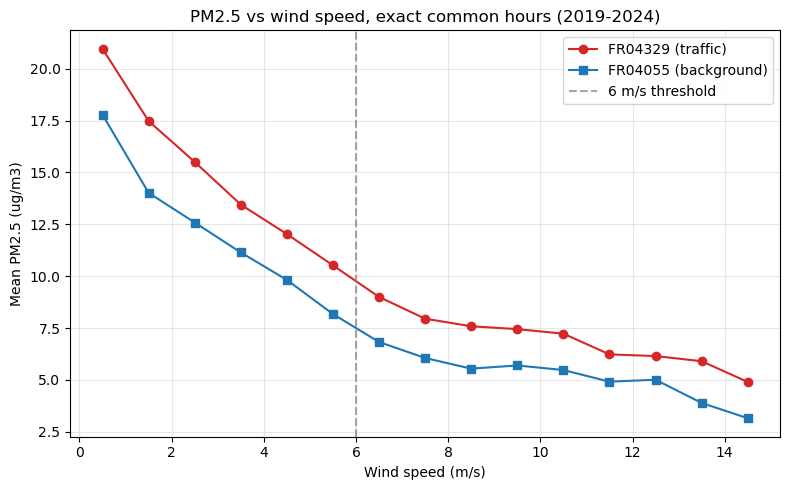

Traffic FR04329 (exact common hours, 2019-2024):
      mean  count
bin              
0.5   21.0    955
1.5   17.5   6939
2.5   15.5   9782
3.5   13.4   8728
4.5   12.0   6410
5.5   10.5   4029
6.5    9.0   2384
7.5    7.9   1295
8.5    7.6    582
9.5    7.4    193
10.5   7.2     76
11.5   6.2     23
12.5   6.1     11
13.5   5.9      2
14.5   4.9      1

Background FR04055 (exact common hours, 2019-2024):
      mean  count
bin              
0.5   17.8    955
1.5   14.0   6939
2.5   12.6   9782
3.5   11.1   8728
4.5    9.8   6410
5.5    8.2   4029
6.5    6.8   2384
7.5    6.1   1295
8.5    5.5    582
9.5    5.7    193
10.5   5.5     76
11.5   4.9     23
12.5   5.0     11
13.5   3.9      2
14.5   3.2      1


In [24]:
import matplotlib.pyplot as plt

def station_series(code):
    station = hourly_valid[hourly_valid["code site"] == code]
    return station.set_index("datetime")["valeur brute"]

common_hours = pd.concat([
    station_series("FR04329").rename("traffic"),
    station_series("FR04055").rename("background"),
    wind,
], axis=1, sort=False).dropna()
common_hours = common_hours.loc["2019-01-01":"2024-12-31 23:59"]

def wind_bins(data, value_column):
    upper_edge = int(np.ceil(data["wind"].max()))
    bins = np.arange(0, upper_edge + 1, 1)
    centers = bins[:-1] + 0.5
    binned = data.copy()
    binned["bin"] = pd.cut(binned["wind"], bins=bins, labels=centers, include_lowest=True)
    return binned.groupby("bin", observed=True)[value_column].agg(["mean", "count"])

traffic = wind_bins(common_hours, "traffic")
background = wind_bins(common_hours, "background")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(traffic.index.astype(float), traffic["mean"], "o-", label="FR04329 (traffic)", color="tab:red")
ax.plot(background.index.astype(float), background["mean"], "s-", label="FR04055 (background)", color="tab:blue")
ax.axvline(6, color="grey", linestyle="--", alpha=0.7, label="6 m/s threshold")
ax.set_xlabel("Wind speed (m/s)")
ax.set_ylabel("Mean PM2.5 (ug/m3)")
ax.set_title("PM2.5 vs wind speed, exact common hours (2019-2024)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Traffic FR04329 (exact common hours, 2019-2024):")
print(traffic.round(1))
print("\nBackground FR04055 (exact common hours, 2019-2024):")
print(background.round(1))

## Figure 2. Annual trends under the three wind conditions

The unfiltered and low-wind trends are both about -4.1% per year. The high-wind trend is shallower, at about -2.9% per year, which matches the direction reported by Renard and Surcin. Its lower R2 indicates greater year-to-year variation around the fitted line; the wider confidence interval, rather than R2 itself, indicates lower precision.

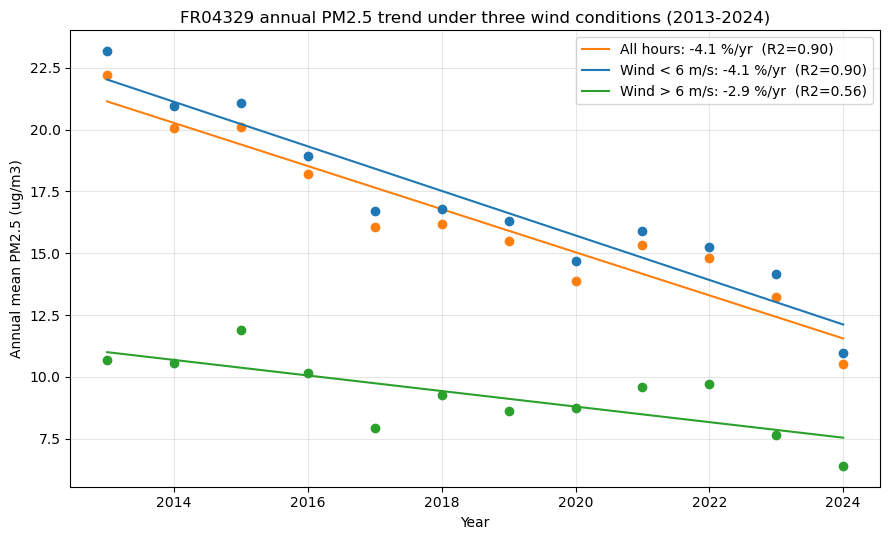

In [25]:
import matplotlib.pyplot as plt
from scipy import stats

def fit_line(ann):
    x = ann.index.values.astype(float)
    res = stats.linregress(x, ann.values)
    trend = 100 * res.slope / (res.slope * x[0] + res.intercept)
    return x, res, trend, res.rvalue**2

fig, ax = plt.subplots(figsize=(9, 5.5))

series = [
    ("All hours",      ann_all,  "tab:orange"),
    ("Wind < 6 m/s",   ann_low,  "tab:blue"),
    ("Wind > 6 m/s",   ann_high, "tab:green"),
]

for label, ann, color in series:
    x, res, trend, r2 = fit_line(ann)
    ax.plot(x, ann.values, "o", color=color, markersize=6)
    ax.plot(x, res.slope * x + res.intercept, "-", color=color,
            label=f"{label}: {trend:+.1f} %/yr  (R2={r2:.2f})")

ax.set_xlabel("Year")
ax.set_ylabel("Annual mean PM2.5 (ug/m3)")
ax.set_title("FR04329 annual PM2.5 trend under three wind conditions (2013-2024)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()